In [1]:
import pandas as pd
import yfinance as yf
import numpy as np

In [2]:
tickers = "ALV.DE BNP.PA IGG.L"
start = "2007-01-01"
end = "2024-01-01"

data = yf.download(
    tickers,
    start=start,
    end=end,
    progress=False
)

print(data.head())

Price           Close                              High             \
Ticker         ALV.DE     BNP.PA       IGG.L     ALV.DE     BNP.PA   
Date                                                                 
2007-01-02  64.975388  35.010574  297.558807  64.975388  35.175914   
2007-01-03  65.398880  35.341267  299.540955  65.598164  35.465272   
2007-01-04  66.200157  35.258591  299.045380  66.490781  35.382593   
2007-01-05  65.266014  34.762577  298.797546  66.200165  35.175925   
2007-01-08  65.365654  34.762577  296.319977  65.515118  35.134591   

Price                         Low                              Open  \
Ticker           IGG.L     ALV.DE     BNP.PA       IGG.L     ALV.DE   
Date                                                                  
2007-01-02  299.788640  64.414894  34.473224  287.400680  64.664004   
2007-01-03  300.284232  64.693078  34.927918  296.320084  64.813477   
2007-01-04  300.779694  64.788554  34.886577  295.576751  65.091632   
2007-01-05  3

In [3]:
close = data["Close"]

In [4]:
close.dropna()

Ticker,ALV.DE,BNP.PA,IGG.L
Date,,,
2007-01-02,64.975388,35.010574,297.558807
2007-01-03,65.398880,35.341267,299.540955
2007-01-04,66.200157,35.258591,299.045380
2007-01-05,65.266014,34.762577,298.797546
2007-01-08,65.365654,34.762577,296.319977
...,...,...,...
2023-12-21,219.925323,53.529705,751.772766
2023-12-22,220.789932,53.640373,758.766052
2023-12-27,219.970840,53.623348,762.262634


In [5]:
close = close.interpolate(method='linear')

In [6]:
import matplotlib.pyplot as plt

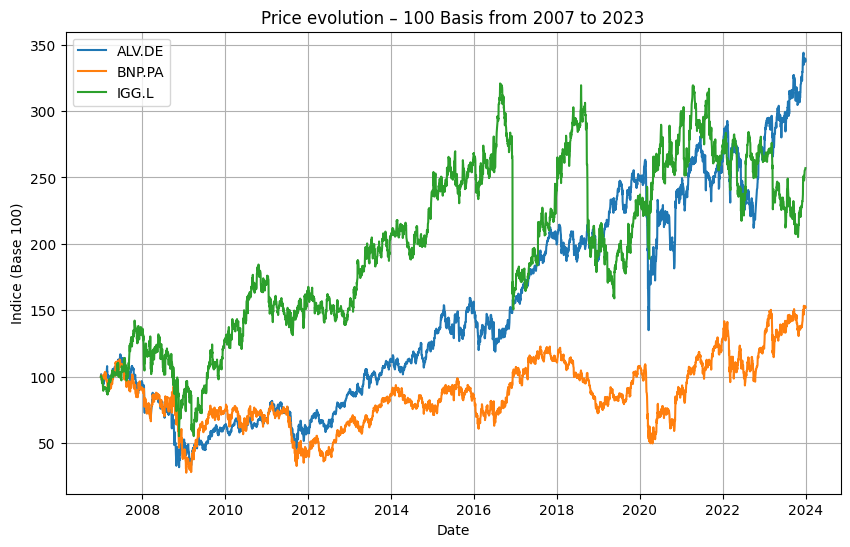

In [39]:
prices_indexed = close / close.iloc[0] * 100

plt.figure(figsize=(10, 6))

for col in prices_indexed.columns:
    plt.plot(prices_indexed.index, prices_indexed[col], label=col)

plt.title("Price evolution – 100 Basis from 2007 to 2023")
plt.xlabel("Date")
plt.ylabel("Indice (Base 100)")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
log_returns = np.log(close).diff().dropna()

In [9]:
log_returns

Ticker,ALV.DE,BNP.PA,IGG.L
Date,,,
2007-01-03,0.006497,0.009401,0.006639
2007-01-04,0.012178,-0.002342,-0.001656
2007-01-05,-0.014211,-0.014168,-0.000829
2007-01-08,0.001526,0.000000,-0.008326
2007-01-09,-0.011756,-0.002381,-0.000836
...,...,...,...
2023-12-21,-0.002480,0.000318,0.003995
2023-12-22,0.003924,0.002065,0.009259
2023-12-27,-0.003717,-0.000317,0.004598


In [10]:
print(log_returns.head())
print(log_returns.describe())


Ticker        ALV.DE    BNP.PA     IGG.L
Date                                    
2007-01-03  0.006497  0.009401  0.006639
2007-01-04  0.012178 -0.002342 -0.001656
2007-01-05 -0.014211 -0.014168 -0.000829
2007-01-08  0.001526  0.000000 -0.008326
2007-01-09 -0.011756 -0.002381 -0.000836
Ticker       ALV.DE       BNP.PA        IGG.L
count   4364.000000  4364.000000  4364.000000
mean       0.000280     0.000096     0.000216
std        0.019067     0.024612     0.022518
min       -0.166382    -0.191166    -0.483873
25%       -0.007365    -0.011232    -0.007941
50%        0.000480     0.000115     0.000628
75%        0.008029     0.011619     0.008392
max        0.233053     0.188745     0.151831


In [11]:
stats = log_returns.describe().T
stats["skew"] = log_returns.skew()
stats["kurtosis"] = log_returns.kurtosis()


In [12]:
stats

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Ticker,,,,,,,,,,
ALV.DE,4364.0,0.000280,0.019067,-0.166382,-0.007365,0.000480,0.008029,0.233053,0.426825,16.298165
BNP.PA,4364.0,0.000096,0.024612,-0.191166,-0.011232,0.000115,0.011619,0.188745,0.004418,8.628336
IGG.L,4364.0,0.000216,0.022518,-0.483873,-0.007941,0.000628,0.008392,0.151831,-3.816933,77.768303


In [13]:
close = close.interpolate(method='linear')

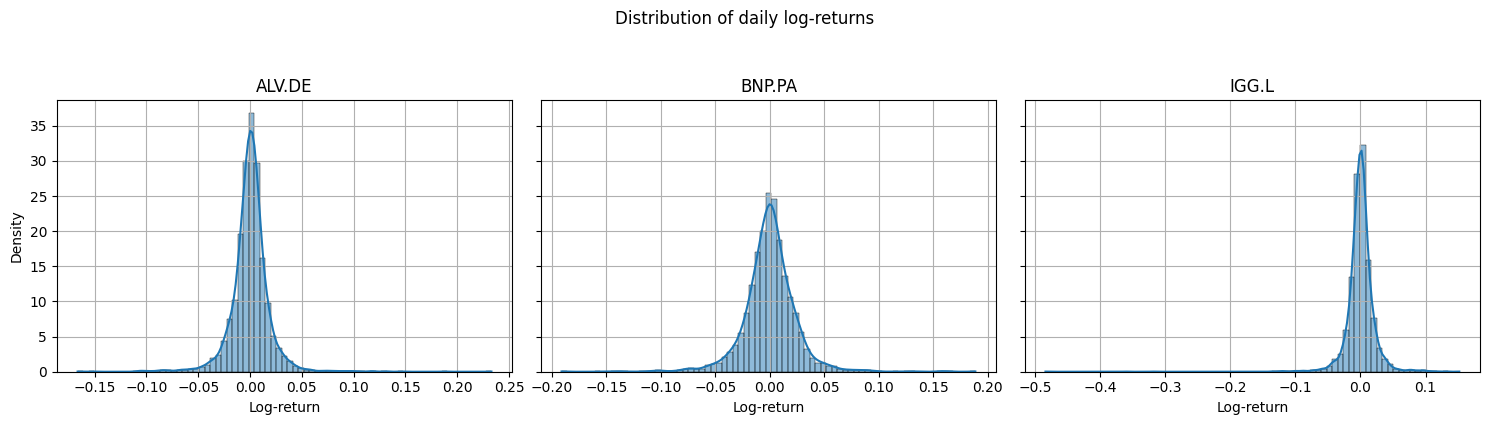

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)

for ax, col in zip(axes, log_returns.columns):
    sns.histplot(
        log_returns[col],
        bins=75,
        stat="density",
        kde=True,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("Log-return")
    ax.grid(True)

axes[0].set_ylabel("Density")
plt.suptitle("Distribution of daily log-returns", y=1.05)
plt.tight_layout()
plt.show()


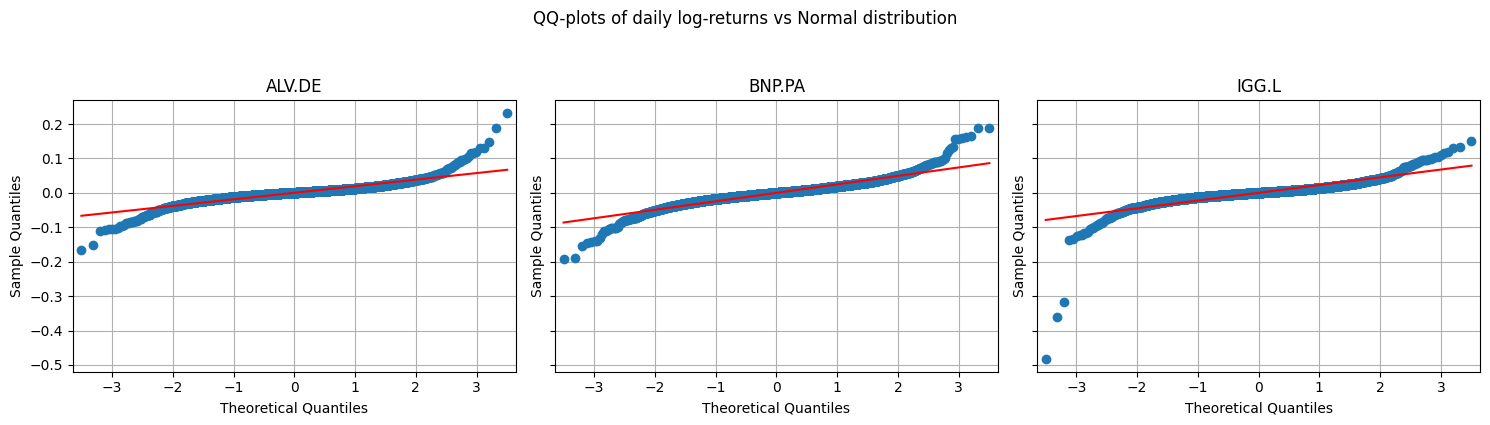

In [15]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)

for ax, col in zip(axes, log_returns.columns):
    sm.qqplot(
        log_returns[col],
        line="s",      # droite ajustée (robuste)
        ax=ax
    )
    ax.set_title(col)
    ax.grid(True)

plt.suptitle("QQ-plots of daily log-returns vs Normal distribution", y=1.05)
plt.tight_layout()
plt.show()


In [16]:
close = close.interpolate(method='linear')

In [17]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name=""):
    stat, pval, _, _, crit, _ = adfuller(series, autolag="AIC")
    print(f"{name}")
    print(f"ADF statistic = {stat:.3f}")
    print(f"p-value = {pval:.4f}")
    print(f"Critical values = {crit}")
    print("-"*30)

# Prix (non stationnaires)
for col in close.columns:
    adf_test(close[col], col + " (prices)")

# Log-returns (stationnaires)
for col in log_returns.columns:
    adf_test(log_returns[col], col + " (returns)")


ALV.DE (prices)
ADF statistic = 0.094
p-value = 0.9657
Critical values = {'1%': -3.4318527927183196, '5%': -2.86220405019551, '10%': -2.5671234784459993}
------------------------------
BNP.PA (prices)
ADF statistic = -1.655
p-value = 0.4544
Critical values = {'1%': -3.431850379108881, '5%': -2.86220298394487, '10%': -2.5671229108274067}
------------------------------
IGG.L (prices)
ADF statistic = -2.182
p-value = 0.2128
Critical values = {'1%': -3.4318517573640657, '5%': -2.862203592811286, '10%': -2.567123234957462}
------------------------------
ALV.DE (returns)
ADF statistic = -13.522
p-value = 0.0000
Critical values = {'1%': -3.4318586867974057, '5%': -2.8622066539957505, '10%': -2.5671248645798315}
------------------------------
BNP.PA (returns)
ADF statistic = -10.672
p-value = 0.0000
Critical values = {'1%': -3.431859731731727, '5%': -2.8622071156110476, '10%': -2.567125110320964}
------------------------------
IGG.L (returns)
ADF statistic = -24.963
p-value = 0.0000
Critical v

In [18]:
alpha = 0.05      # 5% -> VaR 95%
window = 250      # changer à 500/1000 pour tester la robustesse

VaR_HS_95 = log_returns.rolling(window).quantile(alpha)

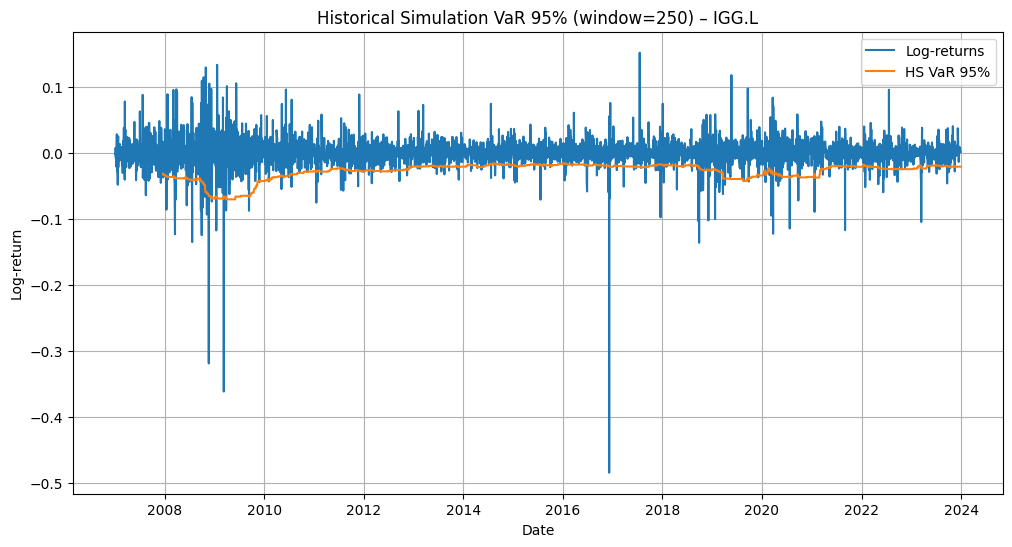

In [19]:
import matplotlib.pyplot as plt

col = log_returns.columns[2
                          ]  # ex: "ALV.DE"

plt.figure(figsize=(12,6))
plt.plot(log_returns.index, log_returns[col], label="Log-returns")
plt.plot(VaR_HS_95.index, VaR_HS_95[col], label="HS VaR 95%")
plt.title(f"Historical Simulation VaR 95% (window={window}) – {col}")
plt.xlabel("Date")
plt.ylabel("Log-return")
plt.legend()
plt.grid(True)
plt.show()



In [20]:
violations = log_returns < VaR_HS_95
hit_rate = violations.mean()

print("VaR 95% violation rate:")
print(hit_rate)


VaR 95% violation rate:
Ticker
ALV.DE    0.051787
BNP.PA    0.050642
IGG.L     0.050183
dtype: float64


In [21]:

def rolling_es(x, alpha=0.05):
    q = np.quantile(x, alpha)
    return x[x <= q].mean()

ES_HS_95 = log_returns.rolling(window).apply(rolling_es, raw=False)

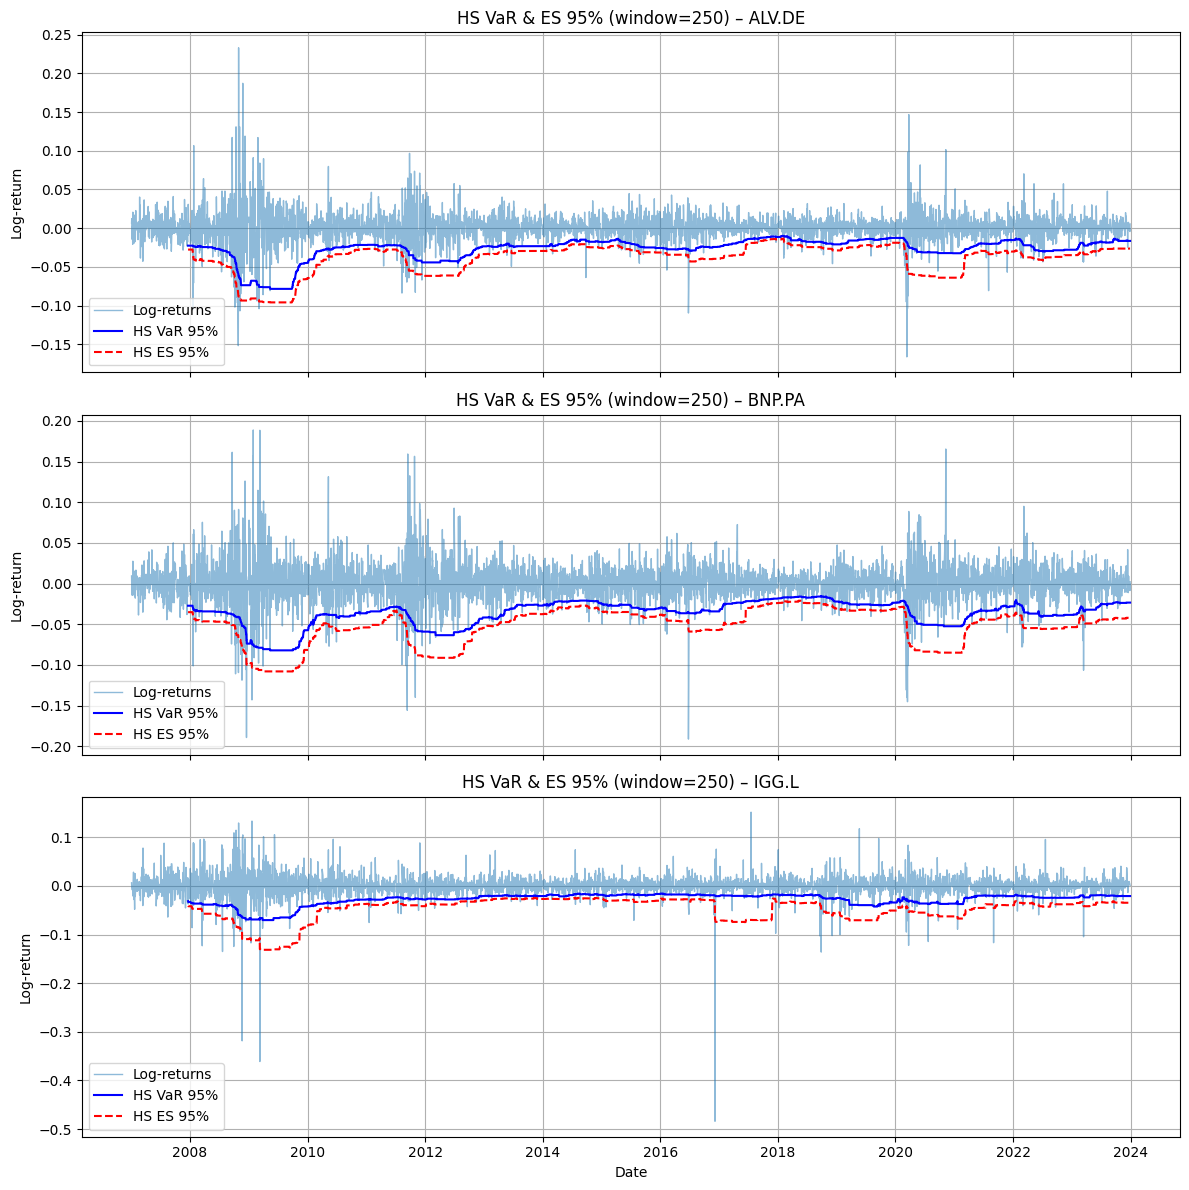

In [22]:
cols = log_returns.columns 

# On crée une figure avec 3 graphiques (axes) l'un en dessous de l'autre
# sharex=True permet d'aligner les dates pour tous les graphiques
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 12), sharex=True)

# On boucle simultanément sur les axes (ax) et les colonnes (col)
for ax, col in zip(axes, cols):
    # Note : ici on utilise 'ax.plot' au lieu de 'plt.plot'
    ax.plot(log_returns.index, log_returns[col], label="Log-returns", alpha=0.5, lw=1)
    ax.plot(VaR_HS_95.index, VaR_HS_95[col], label="HS VaR 95%", color='blue', lw=1.5)
    ax.plot(ES_HS_95.index, ES_HS_95[col], label="HS ES 95%", color='red', linestyle='--', lw=1.5)
    
    ax.set_title(f"HS VaR & ES 95% (window={window}) – {col}")
    ax.set_ylabel("Log-return")
    ax.legend(loc='lower left')
    ax.grid(True)

plt.xlabel("Date")
plt.tight_layout() # Ajuste automatiquement les espacements pour que rien ne se chevauche
plt.show()

In [23]:
check = (ES_HS_95 < VaR_HS_95).mean()
print("Share of dates where ES < VaR:")
print(check)


Share of dates where ES < VaR:
Ticker
ALV.DE    0.942942
BNP.PA    0.942942
IGG.L     0.942942
dtype: float64


In [24]:
from arch import arch_model
from scipy.stats import t

In [25]:
garch_results = {}
garch_params = {}

for col in log_returns.columns:
    r = (log_returns[col].dropna() * 100)  # en %

    am = arch_model(r, mean="Constant", vol="GARCH", p=1, q=1, dist="t")
    res = am.fit(disp="off")

    mu = res.params["mu"]
    nu = res.params["nu"]
    sigma = res.conditional_volatility  # en %

    # --- Student-t NON standardisée (scipy) ---
    q_t = t.ppf(alpha, df=nu)

    # ES pour la t NON standardisée (queue gauche) -> négatif
    es_t = -((nu + q_t**2) / (nu - 1)) * (t.pdf(q_t, df=nu) / alpha)

    # --- Standardisation (variance = 1) pour matcher arch ---
    s = np.sqrt((nu - 2) / nu)   # facteur qui rend Var(z)=1
    q = s * q_t                  # quantile standardisé
    es_std = s * es_t            # ES standardisé (toujours négatif)

    # VaR/ES conditionnels (en décimal)
    VaR = (mu + sigma * q) / 100
    ES  = (mu + sigma * es_std) / 100

    garch_results[col] = pd.DataFrame({"VaR_GARCH": VaR, "ES_GARCH": ES}, index=sigma.index)
    garch_params[col] = res.params


In [26]:
garch_params

{'ALV.DE': mu          0.086487
 omega       0.034491
 alpha[1]    0.089593
 beta[1]     0.904517
 nu          4.471255
 Name: params, dtype: float64,
 'BNP.PA': mu          0.044096
 omega       0.060961
 alpha[1]    0.080945
 beta[1]     0.908865
 nu          6.507554
 Name: params, dtype: float64,
 'IGG.L': mu          0.040000
 omega       0.268178
 alpha[1]    0.165398
 beta[1]     0.805409
 nu          3.021606
 Name: params, dtype: float64}

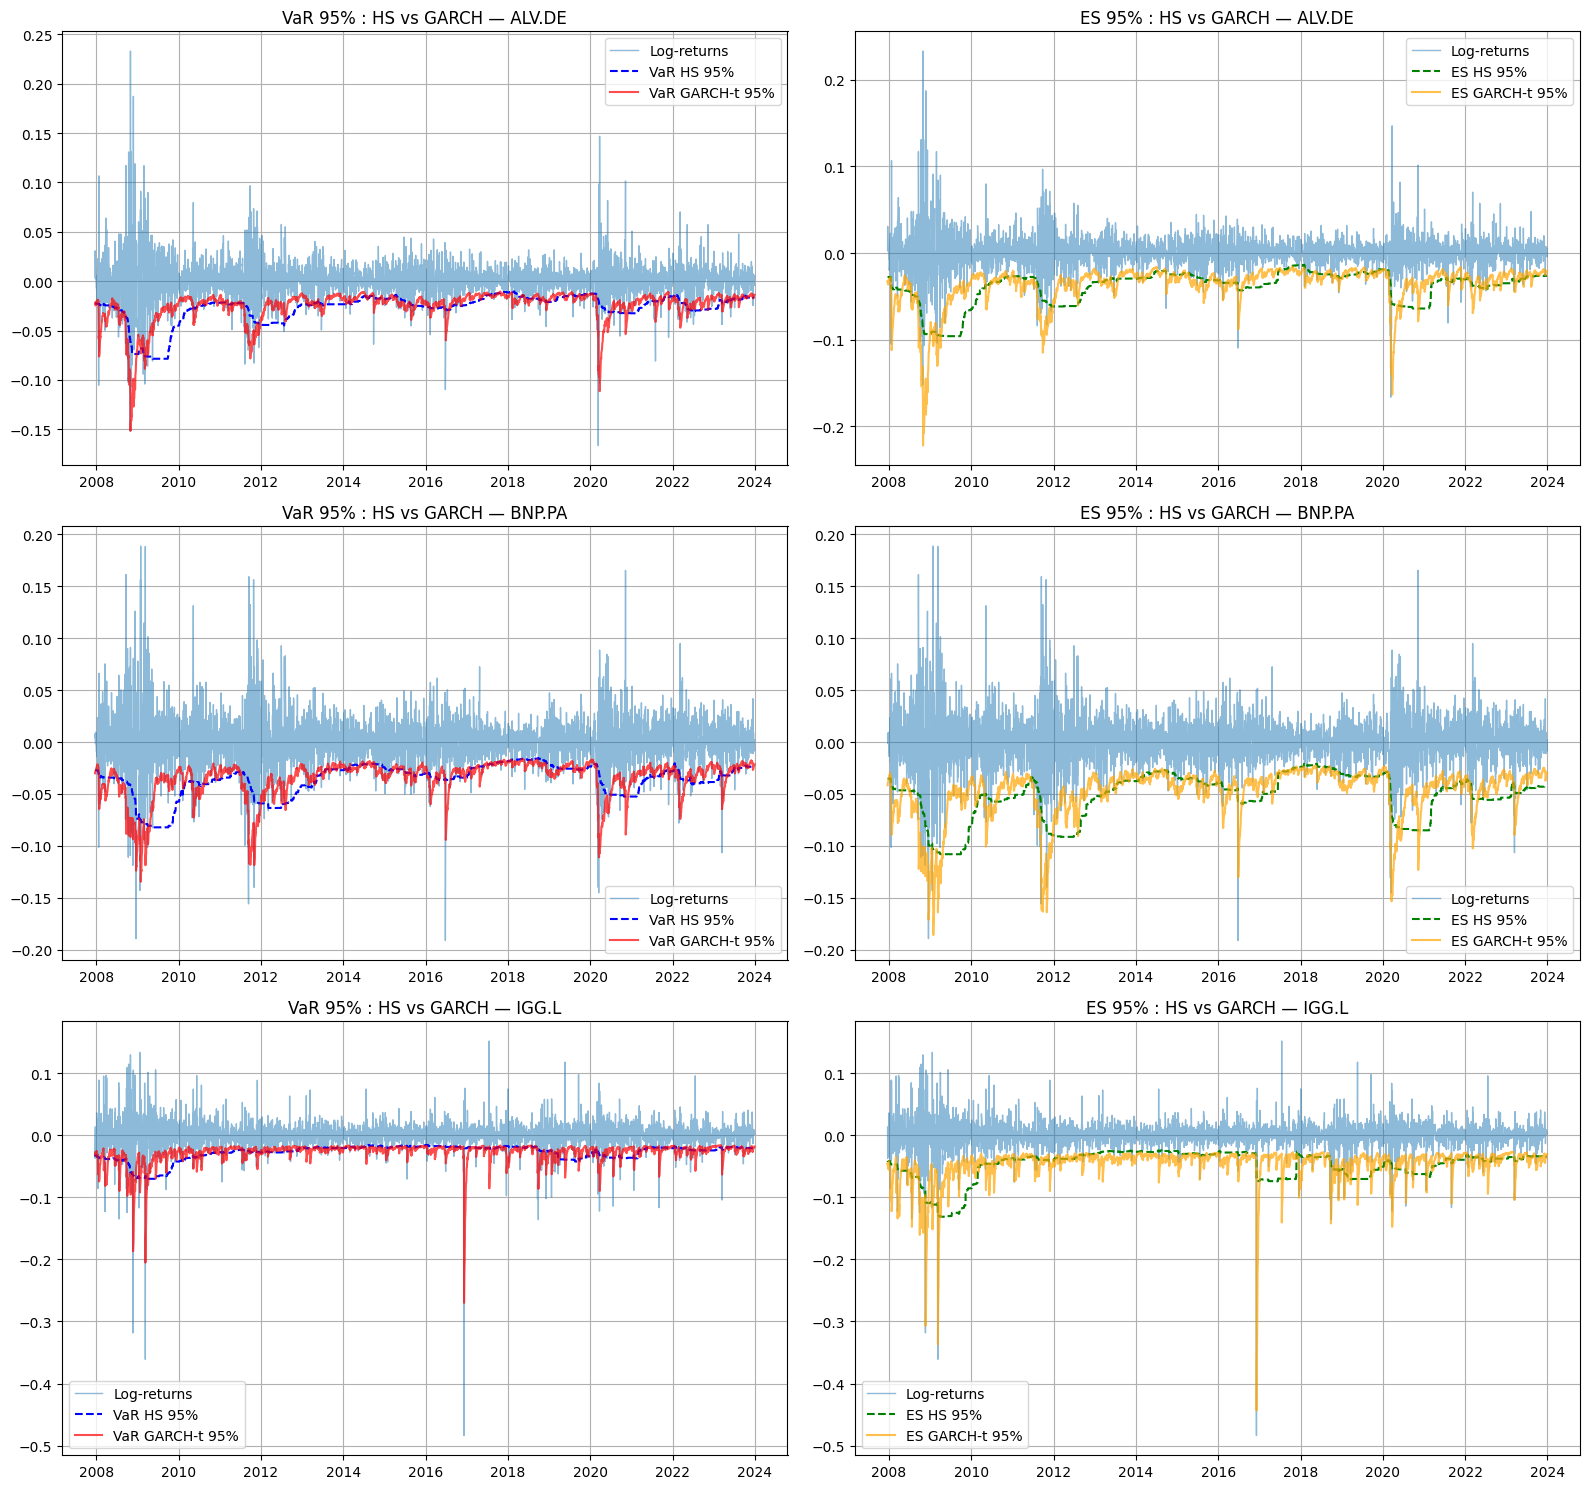

In [27]:
cols = log_returns.columns
n_assets = len(cols)

# On crée une grille : 3 lignes (une par actif), 2 colonnes (VaR à gauche, ES à droite)
# figsize=(Largeur, Hauteur) -> on augmente la hauteur car il y a 3 lignes
fig, axes = plt.subplots(nrows=n_assets, ncols=2, figsize=(16, 5 * n_assets))

for i, col in enumerate(cols):
    # --- 1. Préparation des données pour l'actif en cours (comme ton code) ---
    # On aligne tout et on dropna() pour éviter les trous dans le plot
    df = pd.concat(
        [
            log_returns[col].rename("r"),
            VaR_HS_95[col].rename("VaR_HS"),
            ES_HS_95[col].rename("ES_HS"),
            garch_results[col]["VaR_GARCH"],
            garch_results[col]["ES_GARCH"],
        ],
        axis=1
    ).dropna()

    # --- 2. Récupération des axes ---
    # axes[i, 0] est le graphique de gauche de la ligne i
    # axes[i, 1] est le graphique de droite de la ligne i
    ax_var = axes[i, 0]
    ax_es  = axes[i, 1]

    # --- 3. Graphique de GAUCHE : VaR ---
    ax_var.plot(df.index, df["r"], label="Log-returns", alpha=0.5, lw=1)
    ax_var.plot(df.index, df["VaR_HS"], label="VaR HS 95%", color="blue", linestyle="--")
    ax_var.plot(df.index, df["VaR_GARCH"], label="VaR GARCH-t 95%",alpha=0.7, color="red", linestyle="-")
    
    ax_var.set_title(f"VaR 95% : HS vs GARCH — {col}")
    ax_var.grid(True)
    ax_var.legend()

    # --- 4. Graphique de DROITE : ES ---
    ax_es.plot(df.index, df["r"], label="Log-returns", alpha=0.5, lw=1)
    ax_es.plot(df.index, df["ES_HS"], label="ES HS 95%", color="green", linestyle="--")
    ax_es.plot(df.index, df["ES_GARCH"], label="ES GARCH-t 95%",alpha=0.7, color="orange", linestyle="-")
    
    ax_es.set_title(f"ES 95% : HS vs GARCH — {col}")
    ax_es.grid(True)
    ax_es.legend()

plt.tight_layout() # Indispensable pour que les titres ne chevauchent pas les axes
plt.show()

In [28]:
df

,r,VaR_HS,ES_HS,VaR_GARCH,ES_GARCH
Date,,,,,
2007-12-20,0.013423,-0.031237,-0.041157,-0.028126,-0.046427
2007-12-21,-0.037041,-0.032901,-0.041602,-0.027124,-0.044781
2007-12-24,0.010013,-0.032901,-0.041602,-0.032641,-0.053838
2007-12-27,0.011761,-0.032901,-0.041602,-0.030546,-0.050399
2007-12-28,-0.004317,-0.032901,-0.041602,-0.028942,-0.047766
...,...,...,...,...,...
2023-12-21,0.003995,-0.020664,-0.034454,-0.020193,-0.033403
2023-12-22,0.009259,-0.020664,-0.034454,-0.019486,-0.032243
2023-12-27,0.004598,-0.020664,-0.034454,-0.019414,-0.032125


In [29]:

alpha = 0.05         # VaR/ES 95%
train_window = 1500   # ~6 ans de bourse, ajuste si tu veux

def garch_t_one_step_forecast(r_window, alpha):
    """
    r_window: pd.Series de log-returns en décimal
    retourne VaR_{t+1}, ES_{t+1} en décimal
    """
    r_pct = r_window * 100  # arch en %
    am = arch_model(r_pct, mean="Constant", vol="GARCH", p=1, q=1, dist="t")
    res = am.fit(disp="off")

    mu = res.params["mu"]
    nu = res.params["nu"]
    omega = res.params["omega"]
    a = res.params["alpha[1]"]
    b = res.params["beta[1]"]

    # Dernière observation du window
    eps_t = res.resid.iloc[-1]                 # en %
    sig_t = res.conditional_volatility.iloc[-1] # en %

    # Forecast variance t+1 (en %^2)
    sig2_next = omega + a * (eps_t**2) + b * (sig_t**2)
    sig_next = np.sqrt(sig2_next)

    # Student-t standardisée (variance 1) pour matcher arch
    q_t = t.ppf(alpha, df=nu)
    es_t = -((nu + q_t**2)/(nu - 1)) * (t.pdf(q_t, df=nu) / alpha)
    s = np.sqrt((nu - 2) / nu)
    q = s * q_t
    es_std = s * es_t  # négatif

    VaR_next = (mu + sig_next * q) / 100
    ES_next  = (mu + sig_next * es_std) / 100
    return VaR_next, ES_next

def rolling_garch_forecasts(log_returns, col, train_window, alpha):
    r = log_returns[col].dropna()
    dates = r.index
    VaR_f = []
    ES_f = []
    out_dates = []

    for i in range(train_window, len(r)-1):
        window = r.iloc[i-train_window:i]  # jusqu’à t-1 inclus
        VaR_next, ES_next = garch_t_one_step_forecast(window, alpha=alpha)

        out_dates.append(dates[i])  # date t (où le forecast est fait)
        VaR_f.append(VaR_next)
        ES_f.append(ES_next)

    fc = pd.DataFrame({"VaR_GARCH_fc": VaR_f, "ES_GARCH_fc": ES_f}, index=out_dates)

    # Align: le rendement "réalisé" à t+1
    realized = r.shift(-1).reindex(fc.index).rename("r_next")
    return pd.concat([fc, realized], axis=1).dropna()

# Exemple sur ALV.DE
df_fc = rolling_garch_forecasts(log_returns, "ALV.DE", train_window=train_window, alpha=alpha)
df_fc.head()

,VaR_GARCH_fc,ES_GARCH_fc,r_next
2012-11-01,-0.020707,-0.028831,-0.004068
2012-11-02,-0.020030,-0.027898,-0.003770
2012-11-05,-0.019472,-0.027133,0.011268
2012-11-06,-0.018910,-0.026379,-0.021709
2012-11-07,-0.019034,-0.026538,-0.002016


In [30]:
def garch_t_one_step_forecast(r_window, alpha):
    r_pct = r_window * 100 
    am = arch_model(r_pct, mean="Constant", vol="GARCH", p=1, q=1, dist="t")
    res = am.fit(disp="off")

    mu = res.params["mu"]
    nu = res.params["nu"]
    omega = res.params["omega"]
    a = res.params["alpha[1]"]
    b = res.params["beta[1]"]

    eps_t = res.resid.iloc[-1]
    sig_t = res.conditional_volatility.iloc[-1]

    # Forecast variance t+1
    sig2_next = omega + a * (eps_t**2) + b * (sig_t**2)
    sig_next = np.sqrt(sig2_next)

    # --- Bloc mathématique rigoureux (Standardisation) ---
    # Sécurité : si nu <= 2, la variance est infinie, on force le scaling à 1
    if nu > 2:
        s = np.sqrt((nu - 2) / nu)
    else:
        s = 1 
        
    q_t = t.ppf(alpha, df=nu)
    
    # Formule de l'ES pour Student non-standardisé
    pdf_q = t.pdf(q_t, df=nu)
    es_t = -((nu + q_t**2)/(nu - 1)) * (pdf_q / alpha)
    
    # Ajustement vers variance = 1
    q_std = s * q_t
    es_std = s * es_t

    # Retour à l'échelle décimale
    VaR_next = (mu + sig_next * q_std) / 100
    ES_next  = (mu + sig_next * es_std) / 100
    return VaR_next, ES_next

def rolling_garch_forecasts(log_returns, col, train_window, alpha):
    r = log_returns[col].dropna()
    dates = r.index
    VaR_f = []
    ES_f = []
    out_dates = []

    # On boucle jusqu'à l'avant-dernier jour pour prédire le dernier
    for i in range(train_window, len(r)): 
        # Données disponibles : de 0 à i-1
        window = r.iloc[i-train_window:i] 
        
        # Prévision pour le jour i (date actuelle de la boucle)
        try:
            VaR_next, ES_next = garch_t_one_step_forecast(window, alpha=alpha)
        except:
            VaR_next, ES_next = np.nan, np.nan # En cas d'échec de l'optimiseur

        out_dates.append(dates[i])
        VaR_f.append(VaR_next)
        ES_f.append(ES_next)

    fc = pd.DataFrame({"VaR_GARCH_fc": VaR_f, "ES_GARCH_fc": ES_f}, index=out_dates)

    # CORRECTION ICI : On compare la prévision de 'Mardi' avec le rendement de 'Mardi'
    realized = r.reindex(fc.index).rename("r_next")
    
    return pd.concat([fc, realized], axis=1).dropna()

In [31]:
results_dict = {} 

print("Calcul en cours...")
for col in log_returns.columns:
    # On appelle TA fonction et on stocke le résultat (le fameux "df") dans le dictionnaire
    results_dict[col] = rolling_garch_forecasts(log_returns, col, train_window, alpha)

print("Calculs terminés.\n")

# --- Étape 2 : On calcule le Hit Rate pour chaque actif ---
print(f"{'Actif':<10} | {'Hit Rate (Cible: 5%)':<20} | {'Nb Violations'}")
print("-" * 50)

for asset_name, df_result in results_dict.items():
    # df_result correspond au DataFrame retourné par ta fonction pour cet actif
    
    # Calcul : Est-ce que le rendement réel (r_next) est inférieur à la VaR prévue ?
    # Note : Dans ta fonction, la colonne s'appelle "VaR_GARCH" (et pas "_fc")
    violations = df_result["r_next"] < df_result["VaR_GARCH_fc"]
    
    hit_rate = violations.mean()
    num_violations = violations.sum()
    
    # Affichage
    print(f"{asset_name:<10} | {hit_rate:.2%} ({hit_rate:.4f})   | {num_violations} jours")

Calcul en cours...
Calculs terminés.

Actif      | Hit Rate (Cible: 5%) | Nb Violations
--------------------------------------------------
ALV.DE     | 5.34% (0.0534)   | 153 jours
BNP.PA     | 4.82% (0.0482)   | 138 jours
IGG.L      | 4.96% (0.0496)   | 142 jours


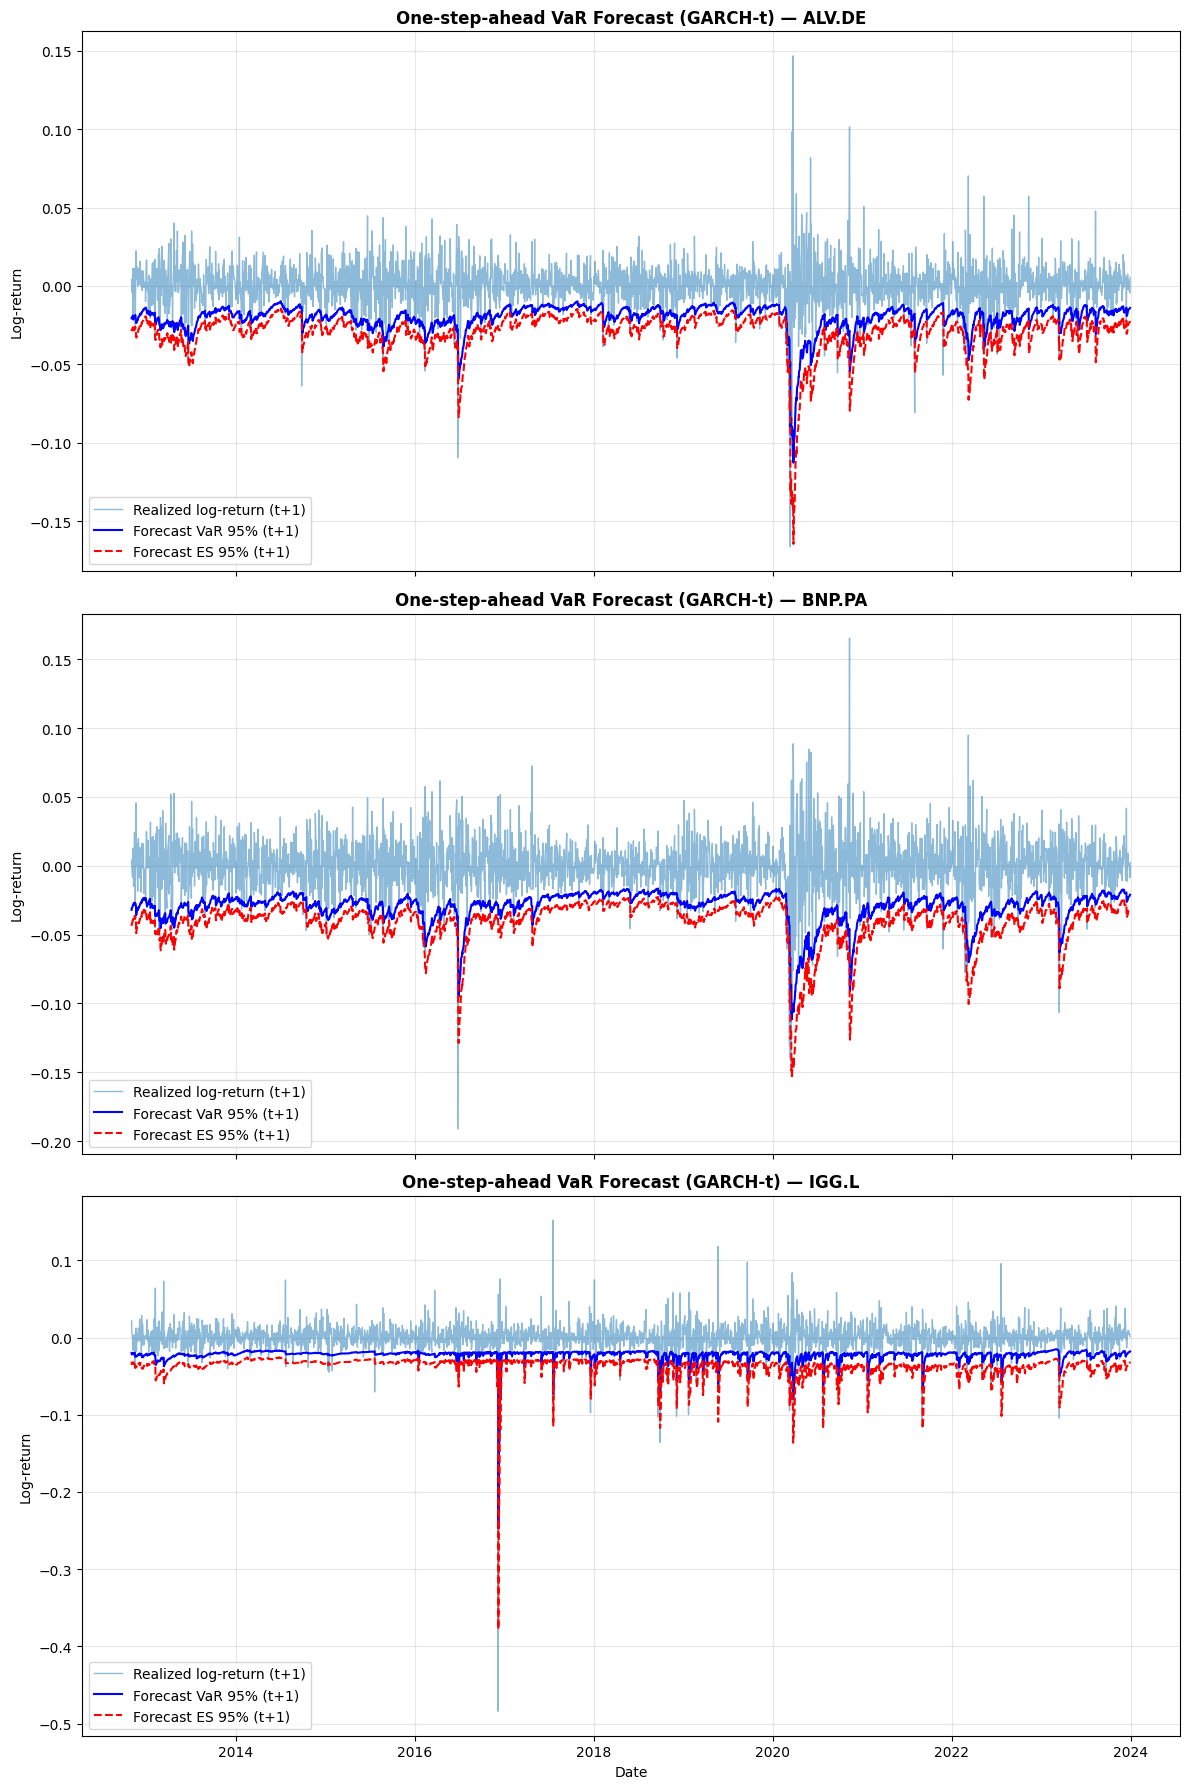

In [32]:
import matplotlib.pyplot as plt

assets = list(results_dict.keys()) 

# Création de la figure avec 3 volets (lignes) superposés
# sharex=True permet de zoomer sur un graph et que les autres suivent
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18), sharex=True)

for i, asset_name in enumerate(assets):
    ax = axes[i]
    df_fc = results_dict[asset_name] # On récupère le DataFrame spécifique à l'actif
    
    # 1. Rendements réalisés (t+1)
    ax.plot(df_fc.index, df_fc["r_next"], label="Realized log-return (t+1)", 
            alpha=0.5, linewidth=1)
    
    # 2. VaR GARCH (Attention au nom de la colonne défini dans ta fonction)
    ax.plot(df_fc.index, df_fc["VaR_GARCH_fc"], label="Forecast VaR 95% (t+1)", 
            color="blue", linewidth=1.5)
    
    # 3. ES GARCH
    ax.plot(df_fc.index, df_fc["ES_GARCH_fc"], label="Forecast ES 95% (t+1)", 
            color="red", linestyle="--", linewidth=1.5)
    
    # Titre et légende pour chaque sous-graphique
    ax.set_title(f"One-step-ahead VaR Forecast (GARCH-t) — {asset_name}", fontweight="bold")
    ax.set_ylabel("Log-return")
    ax.legend(loc="lower left")
    ax.grid(True, alpha=0.3)

# Titre global et ajustements
plt.xlabel("Date")
plt.tight_layout()
plt.show()

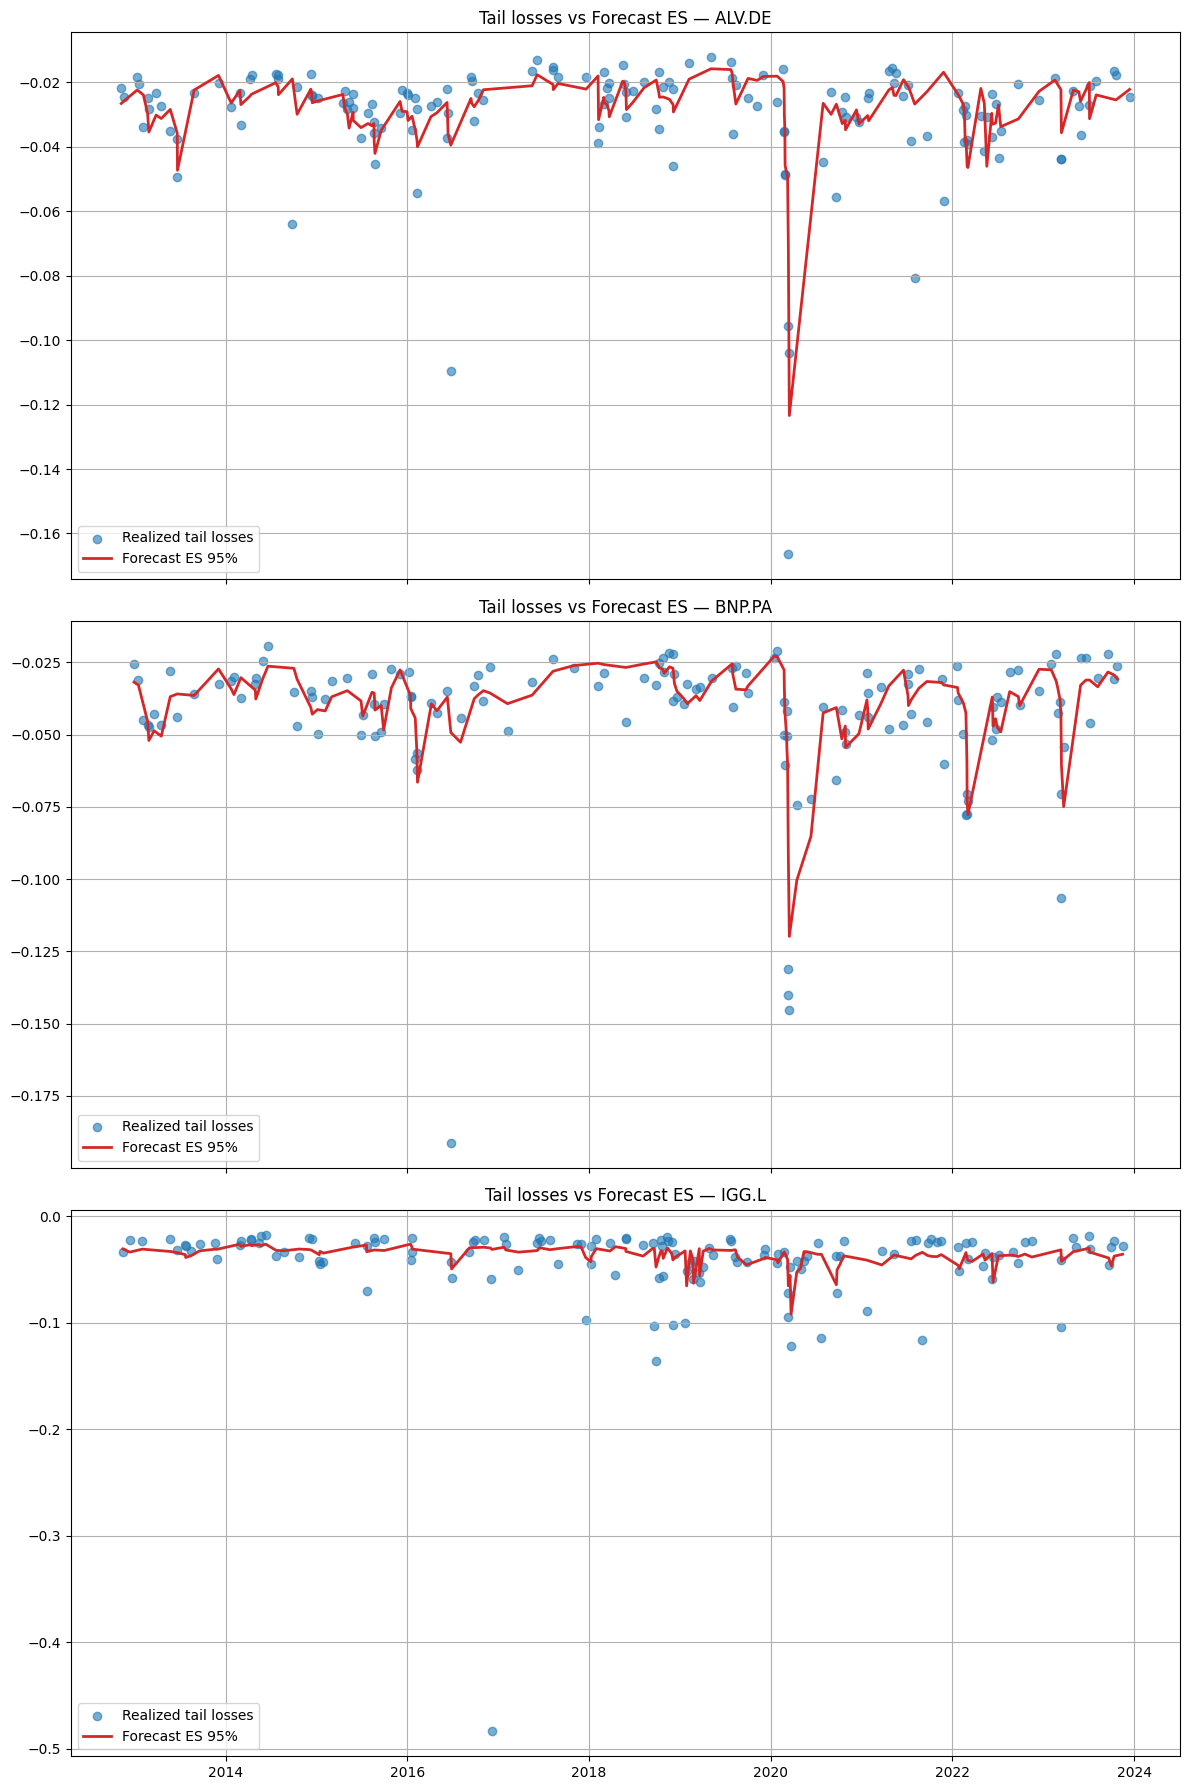

In [34]:
assets = list(results_dict.keys())

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18), sharex=True)

for ax, asset_name in zip(axes, results_dict.keys()):
    df = results_dict[asset_name]
    tail = df[df["r_next"] < df["VaR_GARCH_fc"]]
    
    # --- B. Dessin sur la planche spécifique (ax) ---
    
    # Les points bleus (Scatter) : Les pertes réelles
    ax.scatter(
        tail.index, 
        tail["r_next"], 
        color="tab:blue", 
        alpha=0.6, 
        label="Realized tail losses"
    )

    # La ligne rouge (Plot) : L'ES prévu
    # C'est ici l'astuce : en faisant un .plot() sur 'tail', 
    # Python va relier les points entre eux, même s'ils sont à des dates éloignées.
    # C'est ça qui donne l'effet "ligne brisée" que tu cherches.
    ax.plot(
        tail.index, 
        tail["ES_GARCH_fc"], 
        color="tab:red", 
        linewidth=2, 
        label="Forecast ES 95%"
    )
    
    # --- C. Esthétique ---
    ax.set_title(f"Tail losses vs Forecast ES — {asset_name}")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

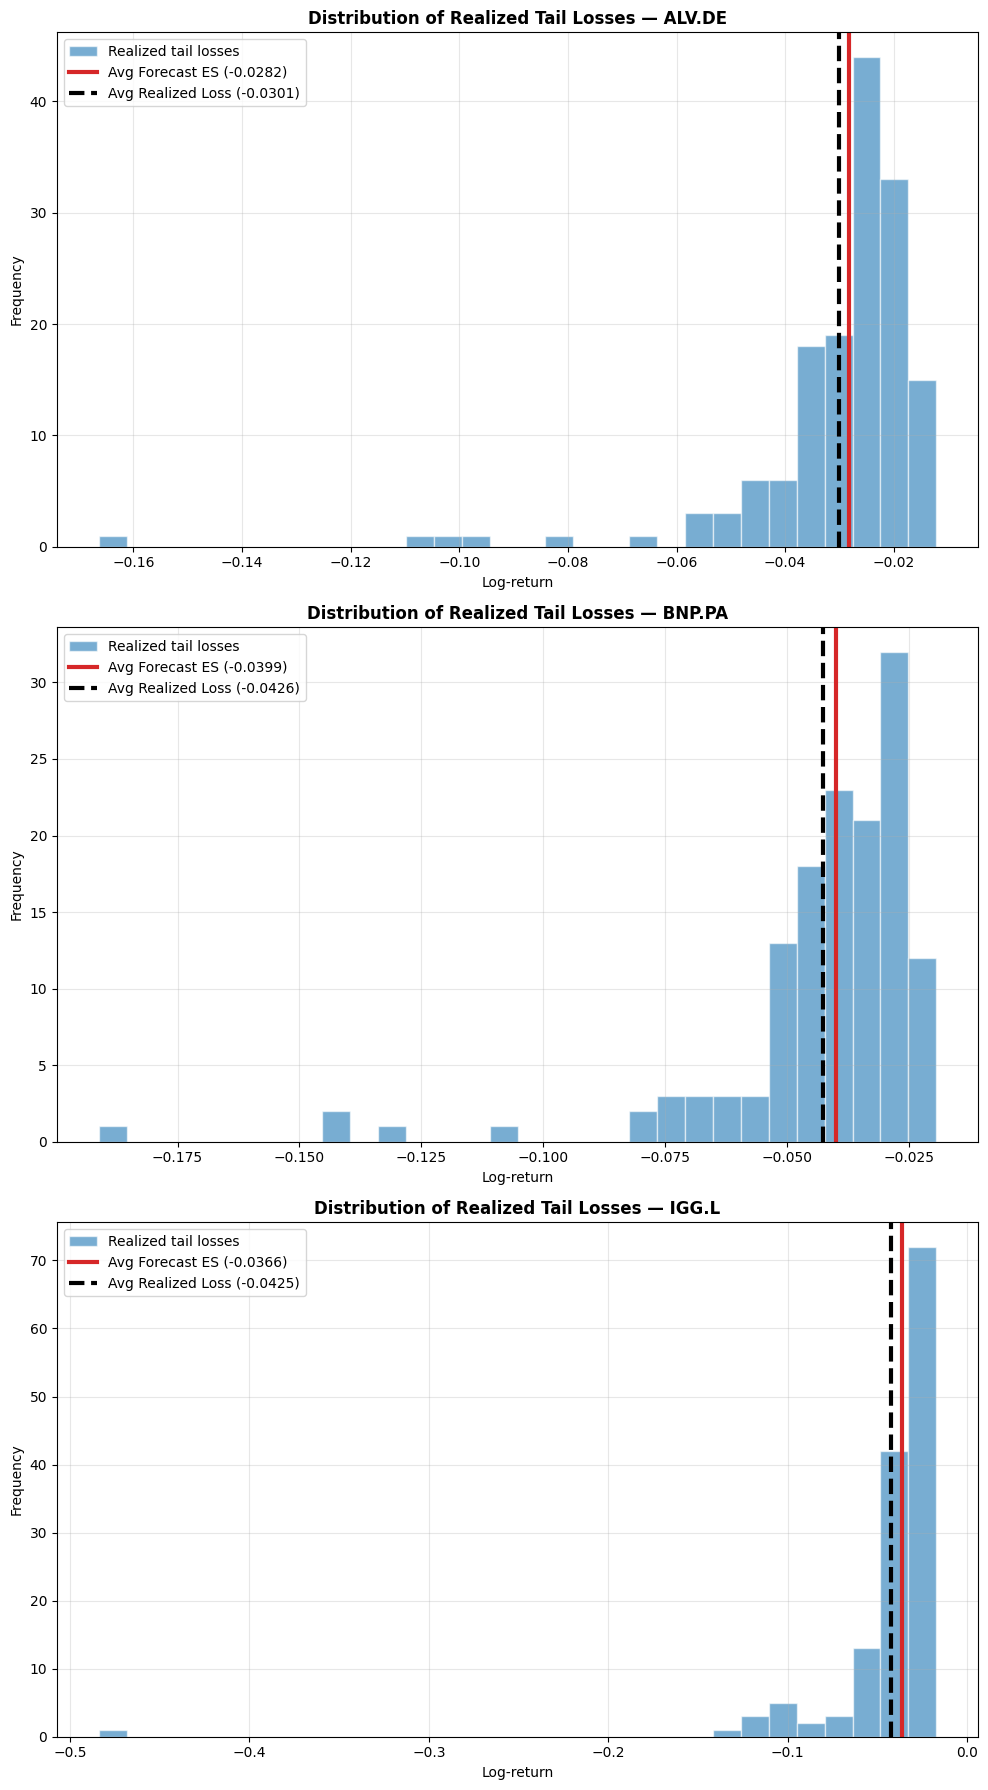

In [38]:
assets = list(results_dict.keys())

# Création de la figure (3 lignes, 1 colonne)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 18))

for i, asset_name in enumerate(assets):
    ax = axes[i]
    df = results_dict[asset_name]
    
    # 1. Filter data to keep only violations (Tail events)
    tail = df[df["r_next"] < df["VaR_GARCH_fc"]]
    
    # Sécurité : Si aucune violation n'est trouvée
    if len(tail) == 0:
        ax.text(0.5, 0.5, "No VaR violations observed", 
                transform=ax.transAxes, ha='center', fontsize=12)
        ax.set_title(f"Distribution of Realized Tail Losses — {asset_name}")
        continue

    # 2. Histogram of Realized Losses (Blue)
    ax.hist(
        tail["r_next"],
        bins=30,
        alpha=0.6,
        color="tab:blue",
        label="Realized tail losses",
        edgecolor='white'
    )

    # 3. Red Line: Average Forecast ES
    avg_es_forecast = tail["ES_GARCH_fc"].mean()
    ax.axvline(
        avg_es_forecast,
        color="tab:red",
        linewidth=3,
        label=f"Avg Forecast ES ({avg_es_forecast:.4f})"
    )

    # 4. Black Dashed Line: Average Realized Loss
    avg_realized_loss = tail["r_next"].mean()
    ax.axvline(
        avg_realized_loss,
        color="black",
        linestyle="--",
        linewidth=3,
        label=f"Avg Realized Loss ({avg_realized_loss:.4f})"
    )

    # 5. Titles and Labels (ENGLISH)
    ax.set_title(f"Distribution of Realized Tail Losses — {asset_name}", fontweight='bold')
    ax.set_xlabel("Log-return")
    ax.set_ylabel("Frequency")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
realized_ES = tail["r_next"].mean()
forecast_ES = tail["ES_GARCH_fc"].mean()

print("Realized tail loss:", realized_ES)
print("Forecast ES:", forecast_ES)


Realized tail loss: -0.030381000991536195
Forecast ES: -0.02789366026726843
